In [ ]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Define the path to the new caves directory
CAVES_DIR = "/home/ga53voq/master_thesis/tasks/cave_exploration/environment/new_caves"

def load_cave_config(cave_index):
    """
    Load cave configuration based on index (1-based indexing)
    """
    cave_dir = f"cave_{cave_index:03d}"
    config_path = os.path.join(CAVES_DIR, cave_dir, "cave_config.json")
    
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Cave config not found: {config_path}")
    
    with open(config_path, 'r') as f:
        config = json.load(f)
    
    return config

def get_voxels_at_x_step(boxes, target_x, voxel_size=0.2, tolerance=0.01):
    """
    Get all voxels at a specific x coordinate (with tolerance for floating point comparison)
    """
    voxels_at_x = []
    for box in boxes:
        box_x = box['position']['x']
        if abs(box_x - target_x - 0.1) <= tolerance:
            voxels_at_x.append(box)
    return voxels_at_x

def get_starting_pos_at_x(starting_positions, target_x, tolerance=0.01):
    """
    Get starting positions at a specific x coordinate
    """
    positions_at_x = []
    for pos in starting_positions:
        if pos and abs(pos['x'] - target_x) <= tolerance:
            positions_at_x.append(pos)
    return positions_at_x

print("Cave analysis utilities loaded successfully!")

Cave analysis utilities loaded successfully!


In [2]:
def analyze_cave_starting_positions(cave_index):
    """
    Analyze a cave's voxel positions and starting positions at x=0.2 intervals
    """
    # Load the cave configuration
    config = load_cave_config(cave_index)
    
    print(f"=== CAVE {cave_index:03d} ANALYSIS ===")
    print(f"Cave ID: {config['generation']['cave_id']}")
    print(f"Voxel size: {config['voxel_size']} m")
    print(f"Total boxes: {config['box_count']}")
    print(f"Target position: x={config['target_pos']['x']:.1f}, y={config['target_pos']['y']:.1f}, z={config['target_pos']['z']:.1f}")
    print(f"Number of starting positions: {len([p for p in config['starting_pos'] if p is not None])}")
    print()
    
    # Get voxel bounds
    bounds = config['voxel_bounds']
    x_min, x_max = bounds['x_min'], bounds['x_max']
    
    # Generate x steps from 0 to max_x with 0.2 intervals
    x_steps = np.arange(0, x_max + 0.2, 0.2)
    
    print("Analysis by X coordinate (every 0.2m):")
    print("=" * 80)
    
    for i, x_coord in enumerate(x_steps):
        print(f"\nX = {x_coord:.1f}m (Step {i+1})")
        print("-" * 40)
        
        # Get voxels at this x coordinate
        voxels_at_x = get_voxels_at_x_step(config['boxes'], x_coord, config['voxel_size'])
        
        # Get starting positions at this x coordinate
        starting_at_x = get_starting_pos_at_x(config['starting_pos'], x_coord)
        
        if voxels_at_x:
            print(f"Voxels found: {len(voxels_at_x)}")
            
            # Extract Y and Z coordinates
            y_coords = [v['position']['y'] for v in voxels_at_x]
            z_coords = [v['position']['z'] for v in voxels_at_x]
            
            print(f"Y range: [{min(y_coords):.1f}, {max(y_coords):.1f}]")
            print(f"Z range: [{min(z_coords):.1f}, {max(z_coords):.1f}]")
            
            # Create a simple grid representation
            print("Voxel positions (Y vs Z):")
            y_unique = sorted(set(y_coords))
            z_unique = sorted(set(z_coords))
            
            if len(y_unique) <= 20 and len(z_unique) <= 20:  # Only show grid if reasonable size
                # Create a simple text grid
                grid = {}
                for v in voxels_at_x:
                    y, z = v['position']['y'], v['position']['z']
                    grid[(y, z)] = '#'
                
                print(f"Grid (Y: {min(y_coords):.1f} to {max(y_coords):.1f}, Z: {min(z_coords):.1f} to {max(z_coords):.1f}):")
                for z in reversed(z_unique):
                    row = f"Z={z:4.1f}: "
                    for y in y_unique:
                        if (y, z) in grid:
                            row += "# "
                        else:
                            row += ". "
                    print(row)
                print(f"         Y: {' '.join([f'{y:4.1f}'[0:2] for y in y_unique])}")
            else:
                print("(Grid too large to display)")
        else:
            print("No voxels found at this X coordinate")
        
        # Display starting positions
        if starting_at_x:
            print(f"\nStarting positions: {len(starting_at_x)}")
            for j, pos in enumerate(starting_at_x):
                print(f"  Start {j+1}: y={pos['y']:.1f}, z={pos['z']:.1f}")
        else:
            print("\nNo starting positions at this X coordinate")
    
    return config

# Test function
print("Analysis function defined successfully!")

Analysis function defined successfully!


In [3]:
# Example usage: Analyze cave 3 (matching the provided config)
cave_index = 3
config = analyze_cave_starting_positions(cave_index)

=== CAVE 003 ANALYSIS ===
Cave ID: 3
Voxel size: 0.2 m
Total boxes: 6799
Target position: x=20.0, y=0.5, z=2.6
Number of starting positions: 97

Analysis by X coordinate (every 0.2m):

X = 0.0m (Step 1)
----------------------------------------
No voxels found at this X coordinate

Starting positions: 1
  Start 1: y=0.0, z=0.4

X = 0.2m (Step 2)
----------------------------------------
No voxels found at this X coordinate

Starting positions: 1
  Start 1: y=0.0, z=0.4

X = 0.4m (Step 3)
----------------------------------------
No voxels found at this X coordinate

Starting positions: 1
  Start 1: y=0.2, z=0.4

X = 0.6m (Step 4)
----------------------------------------
No voxels found at this X coordinate

Starting positions: 1
  Start 1: y=0.2, z=0.4

X = 0.8m (Step 5)
----------------------------------------
No voxels found at this X coordinate

Starting positions: 1
  Start 1: y=0.2, z=0.4

X = 1.0m (Step 6)
----------------------------------------
No voxels found at this X coordinate

In [4]:
# Interactive analysis - Change this number to analyze different caves
print("Available caves: 1 to 300")
print("Change the cave_index below to analyze a different cave:")
print()

# You can change this index to analyze any cave from 1 to 300
CAVE_INDEX_TO_ANALYZE = 1

print(f"Analyzing cave {CAVE_INDEX_TO_ANALYZE}...")
config = analyze_cave_starting_positions(CAVE_INDEX_TO_ANALYZE)

Available caves: 1 to 300
Change the cave_index below to analyze a different cave:

Analyzing cave 1...
=== CAVE 001 ANALYSIS ===
Cave ID: 1
Voxel size: 0.2 m
Total boxes: 6730
Target position: x=20.0, y=0.4, z=0.6
Number of starting positions: 97

Analysis by X coordinate (every 0.2m):

X = 0.0m (Step 1)
----------------------------------------
No voxels found at this X coordinate

Starting positions: 1
  Start 1: y=0.0, z=0.4

X = 0.2m (Step 2)
----------------------------------------
No voxels found at this X coordinate

Starting positions: 1
  Start 1: y=-0.2, z=0.6

X = 0.4m (Step 3)
----------------------------------------
No voxels found at this X coordinate

Starting positions: 1
  Start 1: y=-0.2, z=0.6

X = 0.6m (Step 4)
----------------------------------------
No voxels found at this X coordinate

Starting positions: 1
  Start 1: y=-0.2, z=0.6

X = 0.8m (Step 5)
----------------------------------------
No voxels found at this X coordinate

Starting positions: 1
  Start 1: y=

In [5]:
def visualize_cave_cross_sections(cave_index, x_step_size=0.2, max_plots=10):
    """
    Create visual plots of cave cross-sections at different X coordinates
    """
    config = load_cave_config(cave_index)
    bounds = config['voxel_bounds']
    x_max = bounds['x_max']
    
    # Generate x steps
    x_steps = np.arange(0, x_max + x_step_size, x_step_size)
    
    # Limit number of plots to avoid overwhelming output
    x_steps = x_steps[:max_plots]
    
    # Calculate grid layout
    n_plots = len(x_steps)
    n_cols = min(4, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    if n_plots == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, x_coord in enumerate(x_steps):
        if i >= len(axes):
            break
            
        ax = axes[i]
        
        # Get voxels at this x coordinate
        voxels_at_x = get_voxels_at_x_step(config['boxes'], x_coord, config['voxel_size'])
        starting_at_x = get_starting_pos_at_x(config['starting_pos'], x_coord)
        
        if voxels_at_x:
            # Extract coordinates
            y_coords = [v['position']['y'] for v in voxels_at_x]
            z_coords = [v['position']['z'] for v in voxels_at_x]
            
            # Plot voxels as squares
            voxel_size = config['voxel_size']
            for y, z in zip(y_coords, z_coords):
                rect = plt.Rectangle((y - voxel_size/2, z - voxel_size/2), 
                                   voxel_size, voxel_size, 
                                   facecolor='lightblue', edgecolor='blue', alpha=0.7)
                ax.add_patch(rect)
        
        # Plot starting positions
        if starting_at_x:
            start_y = [p['y'] for p in starting_at_x]
            start_z = [p['z'] for p in starting_at_x]
            ax.scatter(start_y, start_z, c='red', s=50, marker='*', 
                      label='Starting Pos', zorder=5)
        
        ax.set_title(f'X = {x_coord:.1f}m')
        ax.set_xlabel('Y (m)')
        ax.set_ylabel('Z (m)')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        
        # Set consistent axis limits if possible
        if voxels_at_x:
            y_min, y_max = min(y_coords), max(y_coords)
            z_min, z_max = min(z_coords), max(z_coords)
            margin = config['voxel_size']
            ax.set_xlim(y_min - margin, y_max + margin)
            ax.set_ylim(z_min - margin, z_max + margin)
    
    # Hide unused subplots
    for i in range(n_plots, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle(f'Cave {cave_index:03d} Cross-Sections (Y-Z plane at different X coordinates)', 
                 fontsize=16, y=1.02)
    plt.show()

print("Visualization function defined successfully!")

Visualization function defined successfully!


Creating visualization for cave 1...


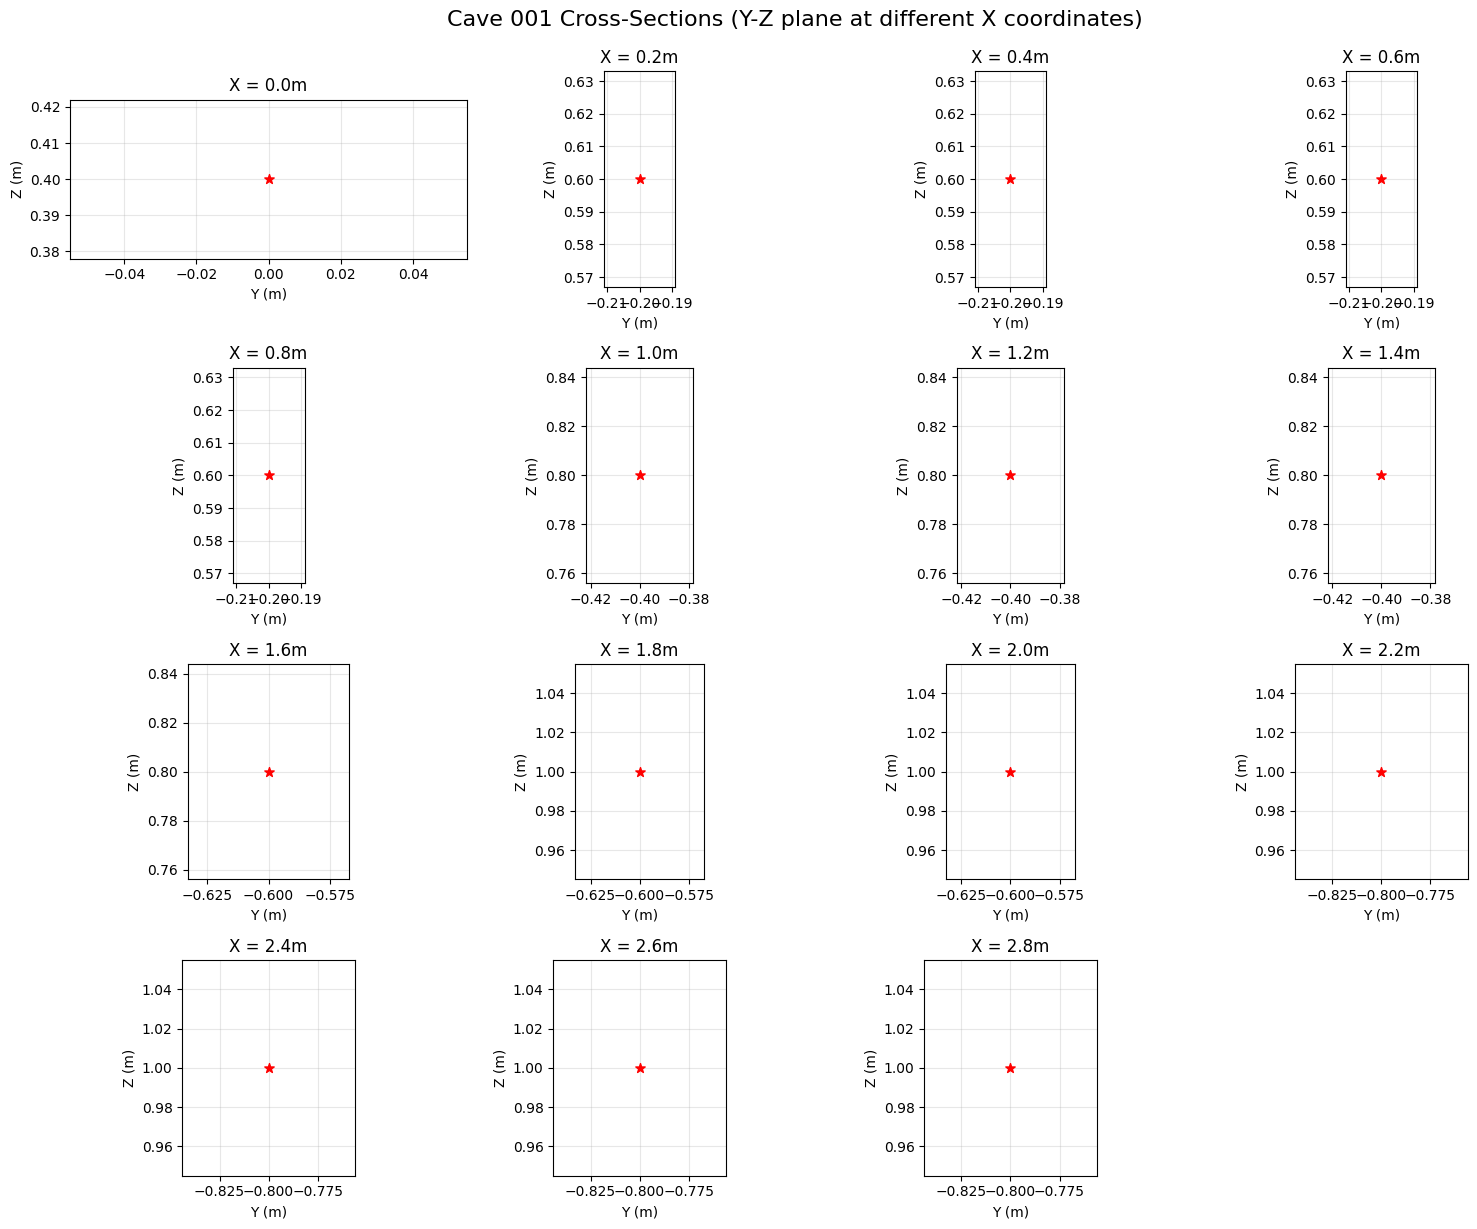

In [6]:
# Visualize the cross-sections for the selected cave
print(f"Creating visualization for cave {CAVE_INDEX_TO_ANALYZE}...")
visualize_cave_cross_sections(CAVE_INDEX_TO_ANALYZE, x_step_size=0.2, max_plots=15)

# Analyze Starting positions